# 02 — Baseline con Downsampling: TF-IDF + Regresión Logística
**Autores:** Giuliano Crenna, Bruno Emmanuel Pace (UGR)  
**Etapa:** 4 — Modelado  

> **NOTA sobre el corpus:** este experimento se entrena sobre un **único corpus** (Coello-Guilarte 2019, 1.047.194 tweets). La generalización a otros corpora en español (kaggle_sdd, reddit_mh_posts traducidos, etc.) no está probada todavía y se abordará cuando se complete el merge de traducciones.

Este notebook entrena la **primera corrida real** sobre datos de Coello-Guilarte (no sintéticos) y resuelve el desbalance 2.48:1 con **downsampling aleatorio** de la clase mayoritaria.

Se comparan dos variantes sobre el mismo split user-level (70/10/20):
1. **Variante A — Downsampled**: train balanceado (212.218 + 212.218 = 424.436 filas), `class_weight=None`.
2. **Variante B — Full + class_weight=balanced**: train completo (700.717 filas), `class_weight="balanced"`.

Métricas headline: **F1-macro** y **AUC OvR macro** (val/test siguen desbalanceados 4.25:1 y 2.56:1 → accuracy es engañosa).

In [1]:
# Parámetros (papermill overrides con -p DATA_DIR ... -p SEED ... -p OUT_DIR ...)
DATA_DIR = "./data"
SEED = 42
OUT_DIR = "reports"
# Random state del downsampling (independiente del SEED global para trazabilidad)
DOWNSAMPLE_SEED = 42

In [2]:
import os
import sys
from pathlib import Path

# Asegurar que la raíz del repositorio esté en el sys.path
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from src.utils.seeds import set_seed
from src.models.train_baseline import load_config, load_split_data
from src.evaluation.metrics import compute

set_seed(SEED)
OUT_DIR = Path(OUT_DIR)
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
MODEL_DIR = REPO_ROOT / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Directorio raíz: {REPO_ROOT}")
print(f"Reportes en: {OUT_DIR.resolve()}")
print(f"Modelos en: {MODEL_DIR.resolve()}")

d:\Github\Deteccion-Temprana-Depresion\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Directorio raíz: D:\Github\Deteccion-Temprana-Depresion
Reportes en: D:\Github\Deteccion-Temprana-Depresion\notebooks\03_baseline\reports
Modelos en: D:\Github\Deteccion-Temprana-Depresion\models


## 1. Carga de splits user-level (Coello-Guilarte)

In [3]:
splits_dir = REPO_ROOT / "data" / "processed" / "splits"
assert (splits_dir / "train.parquet").exists(), (
    f"No se encontró {splits_dir / 'train.parquet'}. "
    f"CWD: {Path.cwd()}. Verificá que el repo esté clonado en {REPO_ROOT}."
)
df_train, df_val, df_test = load_split_data(
    data_dir=splits_dir,
    max_samples=None,
    seed=SEED,
)

# Sanity check contra split_manifest.json
print(f"Train: {len(df_train):,} filas | label counts: {df_train['label'].value_counts().to_dict()}")
print(f"Val:   {len(df_val):,} filas | label counts: {df_val['label'].value_counts().to_dict()}")
print(f"Test:  {len(df_test):,} filas | label counts: {df_test['label'].value_counts().to_dict()}")

expected = {"train": 700717, "val": 95630, "test": 250847}
got = {"train": len(df_train), "val": len(df_val), "test": len(df_test)}
assert got == expected, f"Conteos no coinciden con split_manifest.json: {got} vs {expected}"
print("OK — conteos match con split_manifest.json")

empty_train = int((df_train["text_clean"].astype(str).str.strip() == "").sum())
print(f"Textos vacíos en train (post-anonimización): {empty_train:,}")

2026-09-28 21:11:31 | INFO    | train_baseline | Cargando splits desde D:\Github\Deteccion-Temprana-Depresion\data\processed\splits...


Train: 700,717 filas | label counts: {0: 488499, 2: 212218}
Val:   95,630 filas | label counts: {0: 77425, 2: 18205}
Test:  250,847 filas | label counts: {0: 180347, 2: 70500}
OK — conteos match con split_manifest.json
Textos vacíos en train (post-anonimización): 8,972


## 2. Downsampling aleatorio de la clase mayoritaria (train only)

Se submuestrea `label=0` (control) hasta igualar el conteo de `label=2` (depressive). `val` y `test` se mantienen intactos para evaluar sobre la distribución real.

In [4]:
df_pos = df_train[df_train["label"] == 2]
df_neg = df_train[df_train["label"] == 0].sample(n=len(df_pos), random_state=DOWNSAMPLE_SEED)
df_down = (
    pd.concat([df_pos, df_neg])
    .sample(frac=1.0, random_state=DOWNSAMPLE_SEED)
    .reset_index(drop=True)
)

print(f"Train balanceado (downsampled): {len(df_down):,} filas")
print(f"Distribución: {df_down['label'].value_counts().to_dict()}")

assert len(df_down) == 2 * len(df_pos), "Conteo inesperado en downsampled"
assert df_down["label"].value_counts().to_dict() == {0: len(df_pos), 2: len(df_pos)}, "Desbalance post-downsample"
print("OK — train balanceado exacto")

Train balanceado (downsampled): 424,436 filas
Distribución: {2: 212218, 0: 212218}
OK — train balanceado exacto


## 3. Definición de los dos pipelines TF-IDF + LogReg

Hiperparámetros TF-IDF fijados en `configs/models.yaml`: `ngram_range=(1,2)`, `max_features=15000`, `min_df=2`, `sublinear_tf=true`.

In [5]:
cfg = load_config(REPO_ROOT / "configs" / "models.yaml")
tfidf_cfg = cfg.get("baseline", {}).get("tfidf", {})
logreg_cfg = cfg.get("baseline", {}).get("logreg", {})

def make_tfidf() -> TfidfVectorizer:
    return TfidfVectorizer(
        ngram_range=tuple(tfidf_cfg.get("ngram_range", [1, 2])),
        max_features=int(tfidf_cfg.get("max_features", 15000)),
        min_df=int(tfidf_cfg.get("min_df", 2)),
        sublinear_tf=bool(tfidf_cfg.get("sublinear_tf", True)),
    )

def make_logreg(class_weight) -> LogisticRegression:
    return LogisticRegression(
        C=float(logreg_cfg.get("C", 1.0)),
        class_weight=class_weight,
        max_iter=int(logreg_cfg.get("max_iter", 1000)),
        solver=logreg_cfg.get("solver", "lbfgs"),
        random_state=SEED,
    )

# Variante A — train balanceado, sin class_weight
pipe_down = Pipeline([("tfidf", make_tfidf()), ("clf", make_logreg(class_weight=None))])
# Variante B — train completo, class_weight=balanced
pipe_full = Pipeline([("tfidf", make_tfidf()), ("clf", make_logreg(class_weight="balanced"))])

## 4. Entrenamiento de las dos variantes

In [6]:
X_down = df_down["text_clean"].astype(str).tolist()
y_down = df_down["label"].astype(int).tolist()
X_full = df_train["text_clean"].astype(str).tolist()
y_full = df_train["label"].astype(int).tolist()

print(f"Entrenando Variante A (downsampled) sobre {len(X_down):,} filas...")
pipe_down.fit(X_down, y_down)
print("OK Variante A")

print(f"Entrenando Variante B (full balanced) sobre {len(X_full):,} filas...")
pipe_full.fit(X_full, y_full)
print("OK Variante B")

Entrenando Variante A (downsampled) sobre 424,436 filas...
OK Variante A
Entrenando Variante B (full balanced) sobre 700,717 filas...
OK Variante B


## 5. Evaluación en val y test

In [7]:
def evaluate(pipe: Pipeline, name: str, n_train: int, balance_strategy: str) -> list[dict]:
    from sklearn.metrics import roc_auc_score
    rows = []
    classes = list(pipe.classes_)
    pos_idx = classes.index(2) if 2 in classes else 1  # columna de P(y=depressive)
    for split_name, df_split in [("val", df_val), ("test", df_test)]:
        X = df_split["text_clean"].astype(str).tolist()
        y_true = df_split["label"].astype(int).tolist()
        y_pred = pipe.predict(X)
        y_proba = pipe.predict_proba(X)
        m = compute(y_true, y_pred.tolist(), y_proba=y_proba.tolist())
        # AUC binario directo sobre P(y=2), robusto para labels {0, 2}
        auc_bin = float(roc_auc_score(y_true, y_proba[:, pos_idx]))
        rows.append({
            "model": name,
            "split": split_name,
            "n_train_rows": n_train,
            "class_balance_strategy": balance_strategy,
            "accuracy": m["accuracy"],
            "f1_macro": m["f1_macro"],
            "f1_weighted": m["f1_weighted"],
            "kappa": m["kappa"],
            "auc_binary_depressive": auc_bin,
            "f1_class_0_control": m["report"].get("0", {}).get("f1-score", np.nan),
            "f1_class_2_depressive": m["report"].get("2", {}).get("f1-score", np.nan),
        })
    return rows

rows = []
rows += evaluate(pipe_down, "logreg_downsampled", n_train=len(df_down), balance_strategy="downsample_majority")
rows += evaluate(pipe_full, "logreg_full_balanced", n_train=len(df_train), balance_strategy="class_weight=balanced")

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))

               model split  n_train_rows class_balance_strategy  accuracy  f1_macro  f1_weighted    kappa  auc_binary_depressive  f1_class_0_control  f1_class_2_depressive
  logreg_downsampled   val        424436    downsample_majority  0.697177  0.608901     0.723965 0.238250               0.728978            0.794709               0.423093
  logreg_downsampled  test        424436    downsample_majority  0.686969  0.652843     0.700506 0.317396               0.752695            0.761687               0.543999
logreg_full_balanced   val        700717  class_weight=balanced  0.700220  0.611133     0.726394 0.241718               0.732432            0.797259               0.425007
logreg_full_balanced  test        700717  class_weight=balanced  0.689500  0.654990     0.702772 0.321140               0.755309            0.764106               0.545874


## 6. Persistencia de artefactos

In [8]:
# Modelos
joblib.dump(pipe_down, MODEL_DIR / "logreg_downsampled.joblib")
joblib.dump(pipe_full, MODEL_DIR / "logreg_full_balanced.joblib")
print(f"Modelos guardados en {MODEL_DIR}")

# Métricas
metrics_csv = TAB_DIR / "baseline_downsampled_metrics.csv"
df_metrics.to_csv(metrics_csv, index=False)
print(f"Métricas guardadas en {metrics_csv}")

assert len(df_metrics) == 4, "Debe haber 4 filas (2 modelos × 2 splits)"
assert df_metrics["auc_binary_depressive"].notna().all(), "AUC binario no debe ser NaN"
print("OK — artefactos y métricas consistentes")

Modelos guardados en D:\Github\Deteccion-Temprana-Depresion\models
Métricas guardadas en reports\tables\baseline_downsampled_metrics.csv
OK — artefactos y métricas consistentes


## 7. Matrices de confusión en test

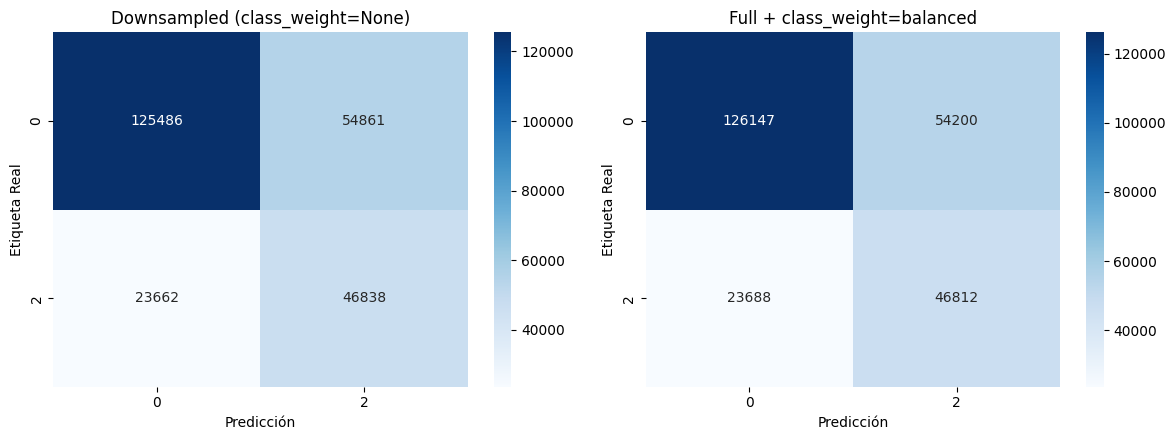

Figura guardada en reports\figures\baseline_downsampled_confusion_matrix.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
y_true = df_test["label"].astype(int).tolist()
labels_unique = sorted(set(y_true))

for idx, (m_name, pipe) in enumerate([
    ("Downsampled (class_weight=None)", pipe_down),
    ("Full + class_weight=balanced", pipe_full),
]):
    y_pred = pipe.predict(df_test["text_clean"].astype(str).tolist())
    cm = confusion_matrix(y_true, y_pred, labels=labels_unique)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=labels_unique, yticklabels=labels_unique)
    axes[idx].set_title(m_name)
    axes[idx].set_xlabel("Predicción")
    axes[idx].set_ylabel("Etiqueta Real")

plt.tight_layout()
fig_path = FIG_DIR / "baseline_downsampled_confusion_matrix.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Figura guardada en {fig_path}")

## 8. Top features del modelo downsampled

Términos que empujan hacia la clase **depressive** (coef > 0) vs **control** (coef < 0).

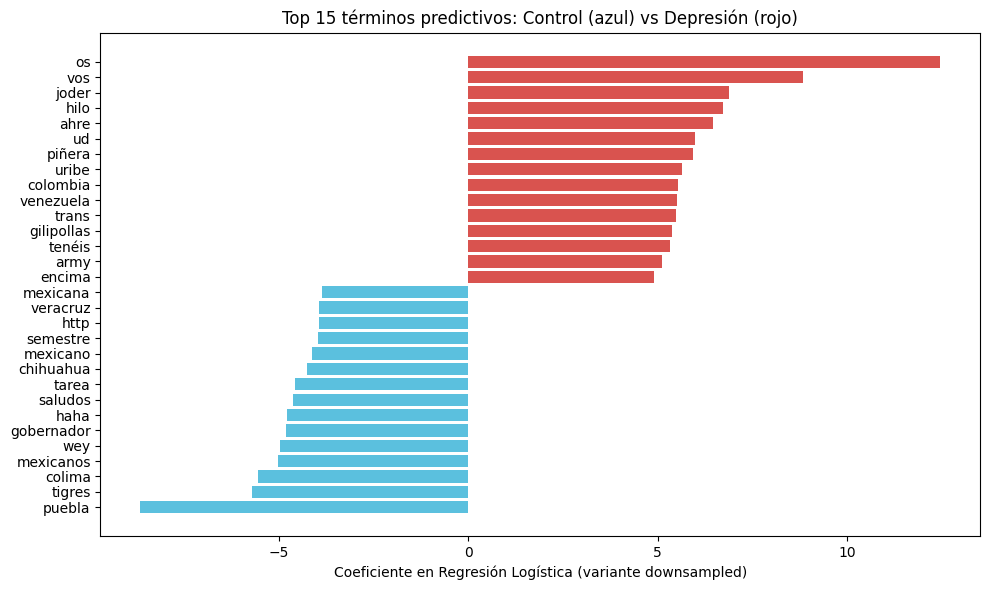

Figura guardada en reports\figures\baseline_downsampled_top_features.png


In [10]:
vec = pipe_down.named_steps["tfidf"]
clf = pipe_down.named_steps["clf"]
feature_names = np.array(vec.get_feature_names_out())
coefs = clf.coef_[0]

top_dep = np.argsort(coefs)[-15:]
top_ctrl = np.argsort(coefs)[:15]

fig, ax = plt.subplots(figsize=(10, 6))
vals = np.concatenate([coefs[top_ctrl], coefs[top_dep]])
words = np.concatenate([feature_names[top_ctrl], feature_names[top_dep]])
colors = ["#d9534f" if c > 0 else "#5bc0de" for c in vals]

y_pos = np.arange(len(words))
ax.barh(y_pos, vals, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(words)
ax.set_xlabel("Coeficiente en Regresión Logística (variante downsampled)")
ax.set_title("Top 15 términos predictivos: Control (azul) vs Depresión (rojo)")
plt.tight_layout()

top_fig_path = FIG_DIR / "baseline_downsampled_top_features.png"
plt.savefig(top_fig_path, dpi=300)
plt.show()
print(f"Figura guardada en {top_fig_path}")

- **AUC binario (clase depressive)** poblado en las 4 corridas → `predict_proba` operativo.